### Logistic Regression trained using Gradient Descent with Binary Cross-Entropy (Log Loss) Loss

##### This notebook implements Logistic Regression from scratch using NumPy.
##### The model:
    1. Calculates a weighted sum of input features
    2. Applies the sigmoid function to produce probabilities
    3. Uses Binary Cross-Entropy (Log Loss) to measure prediction error
    4. Uses Gradient Descent to update weights and bias
    5. Repeats the process over multiple epochs to minimize loss

This demonstrates the core mathematics behind binary classification without using machine learning libraries like scikit-learn.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
                                            df[['age','affordibility']],
                                            df.bought_insurance,
                                            test_size=0.2,
                                            random_state=25
                                            )

In [5]:
X_train_scaled = X_train.copy()
X_train_scaled['age'] = X_train_scaled['age'] / 100

X_test_scaled = X_test.copy()
X_test_scaled['age'] = X_test_scaled['age'] / 100

In [123]:
X_train_scaled.head()

,age,affordibility
0,0.22,1
13,0.29,0
6,0.55,0
17,0.58,1
24,0.50,1


In [8]:
model = keras.Sequential([
    keras.layers.Dense(
                        1,
                        input_shape=(2,),
                        activation='sigmoid',
                        kernel_initializer='ones',
                        bias_initializer='zeros'
                        )
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=5000)

Epoch 1/5000


c:\Users\rehan\anaconda3\envs\py3114\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.5000 - loss: 0.7113
Epoch 2/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.7110
Epoch 3/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7106
Epoch 4/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.7102
Epoch 5/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7098
Epoch 6/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.7094
Epoch 7/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7091
Epoch 8/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7087
Epoch 9/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7083
Epoch 10/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5000 - loss: 0.7079
Epoch 11/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5000 - loss: 0.7076
Epoch 12/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - lo

In [9]:
model.evaluate(X_test_scaled,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.3550


[0.3549776077270508, 1.0]

In [10]:
model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[0.70548487],
       [0.3556957 ],
       [0.16827832],
       [0.47801185],
       [0.72606957],
       [0.8294983 ]], dtype=float32)

In [11]:
y_test

2     1
10    0
21    0
11    0
14    1
9     1
Name: bought_insurance, dtype: int64

In [12]:
coef, intercept = model.get_weights()

In [13]:
coef, intercept

(array([[5.060863 ],
        [1.4086521]], dtype=float32),
 array([-2.913703], dtype=float32))

This means w1=5.060867, w2=1.4086502, bias =-2.9137027

In [21]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [22]:
sigmoid(18)

np.float64(0.9999999847700205)

In [23]:
def prediction_function(age, affordibility):
    weighted_sum = coef[0]*age + coef[1]*affordibility + intercept
    return sigmoid(weighted_sum)

In [24]:
prediction_function(.47,1)

array([0.7054848], dtype=float32)

In [25]:
prediction_function(.18, 1)

array([0.3556957], dtype=float32)

#### Writing own gradient descent in plain python

In [32]:
np.exp(1)

np.float64(2.718281828459045)

### Sigmoid function

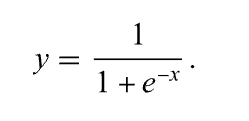

In [26]:
def sigmoid_numpy(X):
   return 1/(1+np.exp(-X))

sigmoid_numpy(np.array([12,0,1]))

array([0.99999386, 0.5       , 0.73105858])

In [87]:
sigmoid_numpy(np.array([1.22]))

array([0.77206355])

### Log Loss function

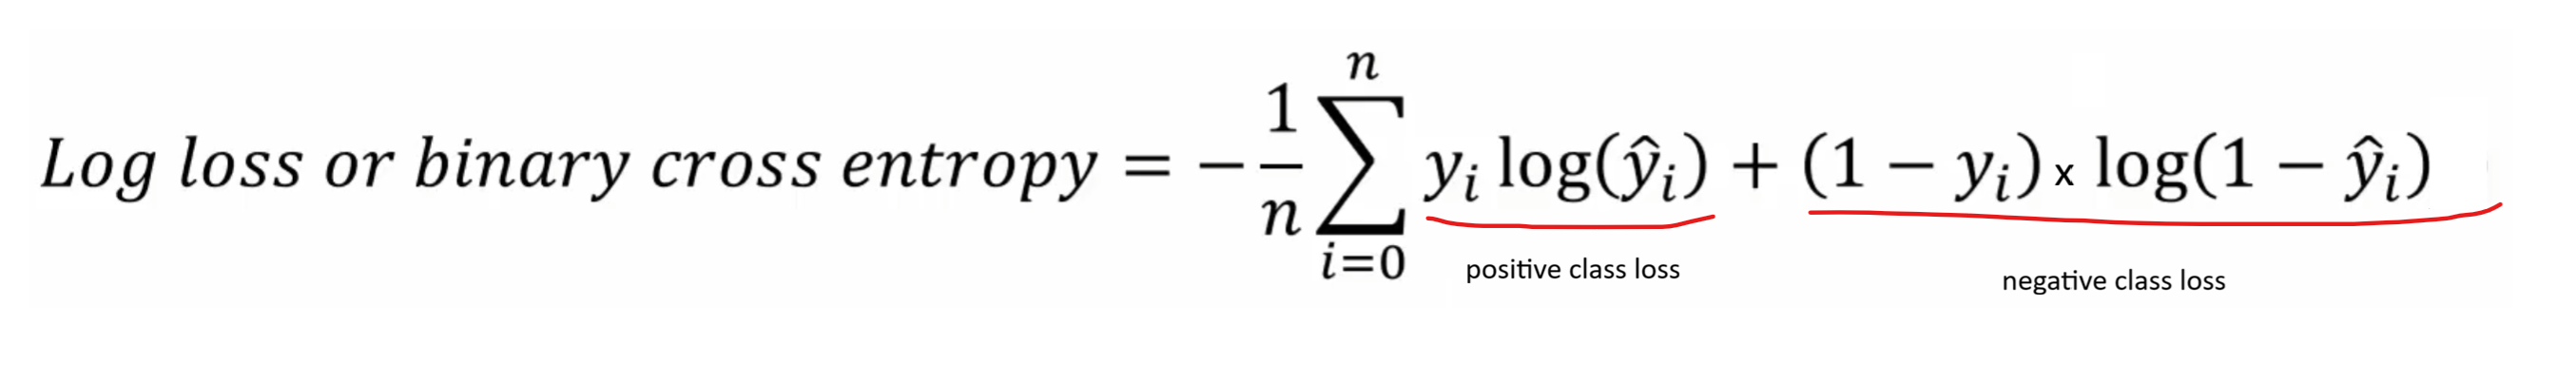

In [47]:
# this is for checking only
y_true = np.array([1,1,1,0,0,0])
y_predicted = np.array([1,1,0,1,0,0])

In [67]:
def log_loss(y_true, y_predicted):

    epsilon = 1e-15

    # Avoid log(0) because in the formula, we are taking the log of the predictions
    y_predicted = np.clip(y_predicted, epsilon, 1 - epsilon)

    positive_class_loss = y_true * np.log(y_predicted)

    negative_class_loss = (1 - y_true) * np.log(1 - y_predicted)

    total_loss = -(positive_class_loss + negative_class_loss)

    average_loss = np.mean(total_loss)

    return average_loss

In [140]:
y_train.to_clipboard()

In [141]:
def gradient_descent(age, affordability, y_true, epochs, loss_thresold):

    # Initialize weights as 1 and bias as 0
    w1 = w2 = 1
    bias = 0

    # Learning rate controls how big each update step is
    rate = 0.5

    # Number of training examples
    n = len(age)

    # Run training loop
    for i in range(epochs):

        # Linear equation:
        #     z =      w1 * x1  + w2 * x2            + bias
        weighted_sum = w1 * age + w2 * affordability + bias

        # Apply sigmoid to convert values into probabilities
        y_predicted = sigmoid_numpy(weighted_sum)


        # Calculate prediction error using log loss
        loss = log_loss(y_true, y_predicted)

        # Partial derivative for w1
        # Measures how much w1 affects the loss
        print("np.transpose.......", np.transpose(age))

        print("diff function.......",(y_predicted - y_true))

        w1d = (1/n) * np.dot(np.transpose(age), (y_predicted - y_true))
        
        # Partial derivative for w2
        w2d = (1/n) * np.dot(np.transpose(affordability), (y_predicted - y_true))

        # Partial derivative for bias
        bias_d = np.mean(y_predicted - y_true)

        # Update weights and bias
        # Move opposite direction of gradient to reduce loss
        w1 = w1 - rate * w1d
        w2 = w2 - rate * w2d
        bias = bias - rate * bias_d

        # Print progress after each epoch
        print(f'Epoch:{i}, w1:{w1}, w1d:{w1d}, w2:{w2},w2d:{w2d}, bias:{bias}, loss:{loss}')

        # Stop early if loss becomes small enough
        if loss <= loss_thresold:
            break

    # Return final learned parameters
    return w1, w2, bias, y_predicted

In [143]:
y_predicted

array([1.e+00, 1.e+00, 1.e-15, 1.e+00, 1.e-15, 1.e-15])

In [142]:
gradient_descent(
    X_train_scaled['age'],
    X_train_scaled['affordibility'],
    y_train,
    1,
    0.4631
    )

np.transpose....... 0     0.22
13    0.29
6     0.55
17    0.58
24    0.50
19    0.18
25    0.54
16    0.25
20    0.21
3     0.52
7     0.60
1     0.25
5     0.56
27    0.46
8     0.62
18    0.19
12    0.27
23    0.45
22    0.40
15    0.55
26    0.23
4     0.46
Name: age, dtype: float64
diff function....... 0     0.772064
13    0.571996
6     0.634136
17   -0.170795
24   -0.182426
19    0.764948
25   -0.176535
16   -0.437823
20    0.770299
3     0.627148
7    -0.354344
1     0.562177
5    -0.173647
27    0.811533
8    -0.165205
18    0.547358
12    0.567093
23   -0.190002
22   -0.197816
15   -0.175086
26    0.773819
4    -0.188467
dtype: float64
Epoch:0, w1:0.974907633470177, w1d:0.050184733059646054, w2:0.948348125394529,w2d:0.10330374921094214, bias:-0.11341867736368583, loss:0.7113403233723417


(np.float64(0.974907633470177),
 np.float64(0.948348125394529),
 np.float64(-0.11341867736368583),
 0     0.772064
 13    0.571996
 6     0.634136
 17    0.829205
 24    0.817574
 19    0.764948
 25    0.823465
 16    0.562177
 20    0.770299
 3     0.627148
 7     0.645656
 1     0.562177
 5     0.826353
 27    0.811533
 8     0.834795
 18    0.547358
 12    0.567093
 23    0.809998
 22    0.802184
 15    0.824914
 26    0.773819
 4     0.811533
 dtype: float64)